# 03 — Modeling & Experiment Tracking

Melatih & melacak model churn: **baseline 3 model → tuning → threshold → business impact → simpan final**.
Semua artifact Hari 2 (preprocessor + split) dipakai ulang; tracking via MLflow (SQLite backend).

## 1. Setup & Load Artifact (Hari 2)

In [1]:
# === Semua import dikumpulkan di sini (stdlib -> third-party -> lokal) ===
import sys, json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow
import mlflow.sklearn
import mlflow.xgboost

import optuna
from optuna.samplers import TPESampler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
)

# modul preprocessing reusable dari Hari 2
sys.path.append("..")
from src.preprocessing import split_columns, build_preprocessor

In [2]:
# ROOT = folder project (1 level di atas notebooks/)
ROOT = Path.cwd().parent
print("ROOT project:", ROOT)

assert (ROOT / "models/preprocessor.joblib").exists(), "preprocessor.joblib belum ada! Run Hari 2 dulu."
assert (ROOT / "models/split_data.joblib").exists(), "split_data.joblib belum ada! Run Hari 2 dulu."
print("Artifact Hari 2 ditemukan")

ROOT project: D:\Coding Vscode\telco-churn-prediction
Artifact Hari 2 ditemukan


In [3]:
# Load preprocessor (sudah di-FIT di Hari 2) & data split
preprocessor = joblib.load(ROOT / "models/preprocessor.joblib")
X_train, X_test, y_train, y_test = joblib.load(ROOT / "models/split_data.joblib")

# .transform() saja (preprocessor sudah di-fit di Hari 2 -> no leakage)
X_tr = preprocessor.transform(X_train)
X_te = preprocessor.transform(X_test)

print("Train:", X_tr.shape, "| churn rate:", round(y_train.mean(), 3))
print("Test :", X_te.shape, "| churn rate:", round(y_test.mean(), 3))

Train: (5634, 52) | churn rate: 0.265
Test : (1409, 52) | churn rate: 0.265


In [4]:
# Setup MLflow (SQLite backend, experiment sama dgn Hari 2)
mlflow.set_tracking_uri(f'sqlite:///{(ROOT / "mlflow.db").as_posix()}')
mlflow.set_experiment("telco-churn")
print("MLflow siap ->", mlflow.get_tracking_uri())

MLflow siap -> sqlite:///D:/Coding Vscode/telco-churn-prediction/mlflow.db


## 2. Baseline Models

Melatih 3 model dgn penanganan imbalance (`class_weight='balanced'` / `scale_pos_weight`).
Helper `train_and_log` melatih, evaluasi di test set, dan mencatat ke MLflow.

In [5]:
def train_and_log(model, model_name, params):
    '''Train 1 model, evaluasi di test set, log ke MLflow. Return dict metrik.'''
    with mlflow.start_run(run_name=model_name):
        mlflow.log_params(params)
        model.fit(X_tr, y_train)

        y_pred = model.predict(X_te)
        y_proba = model.predict_proba(X_te)[:, 1]
        metrics = {
            "accuracy":  accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred),
            "recall":    recall_score(y_test, y_pred),
            "f1":        f1_score(y_test, y_pred),
            "roc_auc":   roc_auc_score(y_test, y_proba),
        }
        mlflow.log_metrics(metrics)

        if "XGB" in type(model).__name__:
            mlflow.xgboost.log_model(model, name="model")
        else:
            mlflow.sklearn.log_model(model, name="model")

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        print(f"=== {model_name} ===")
        for k, v in metrics.items():
            print(f"  {k:10s}: {v:.4f}")
        print(f"  Confusion : TN={tn} FP={fp} FN={fn} TP={tp} (nangkep {tp}/{tp+fn} churner)")
    return metrics

### 2.1 Logistic Regression
Baseline linear — cepat, interpretable, jadi titik referensi.

In [6]:
params_logreg = {
    "model_type": "LogisticRegression",
    "C": 1.0, "class_weight": "balanced",
    "max_iter": 1000, "solver": "lbfgs", "random_state": 42,
}
sklearn_params = {k: v for k, v in params_logreg.items() if k != "model_type"}
model_logreg = LogisticRegression(**sklearn_params)
metrics_logreg = train_and_log(model_logreg, "logreg-baseline", params_logreg)

=== logreg-baseline ===
  accuracy  : 0.7331
  precision : 0.4983
  recall    : 0.7914
  f1        : 0.6116
  roc_auc   : 0.8419
  Confusion : TN=737 FP=298 FN=78 TP=296 (nangkep 296/374 churner)


### 2.2 Random Forest
Ensemble pohon — menangkap interaksi fitur non-linear.

In [7]:
params_rf = {
    "model_type": "RandomForest",
    "n_estimators": 200, "max_depth": 10, "min_samples_split": 20,
    "class_weight": "balanced", "random_state": 42, "n_jobs": -1,
}
sklearn_params = {k: v for k, v in params_rf.items() if k != "model_type"}
model_rf = RandomForestClassifier(**sklearn_params)
metrics_rf = train_and_log(model_rf, "randomforest-baseline", params_rf)

=== randomforest-baseline ===
  accuracy  : 0.7679
  precision : 0.5453
  recall    : 0.7567
  f1        : 0.6338
  roc_auc   : 0.8415
  Confusion : TN=799 FP=236 FN=91 TP=283 (nangkep 283/374 churner)


### 2.3 XGBoost
Gradient boosting — pohon dibangun sekuensial. `scale_pos_weight` untuk imbalance.

In [8]:
# XGBoost tak punya class_weight='balanced' -> pakai scale_pos_weight = neg/pos
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

params_xgb = {
    "model_type": "XGBoost",
    "n_estimators": 300, "max_depth": 6, "learning_rate": 0.1,
    "subsample": 0.8, "colsample_bytree": 0.8,
    "scale_pos_weight": scale_pos_weight,
    "random_state": 42, "n_jobs": -1, "eval_metric": "logloss",
}
sklearn_params = {k: v for k, v in params_xgb.items() if k != "model_type"}
model_xgb = XGBClassifier(**sklearn_params)
metrics_xgb = train_and_log(model_xgb, "xgboost-baseline", params_xgb)

=== xgboost-baseline ===
  accuracy  : 0.7608
  precision : 0.5400
  recall    : 0.6684
  f1        : 0.5974
  roc_auc   : 0.8181
  Confusion : TN=822 FP=213 FN=124 TP=250 (nangkep 250/374 churner)


### 2.4 Perbandingan 3 Model

In [9]:
comparison = pd.DataFrame({
    "LogisticRegression": metrics_logreg,
    "RandomForest": metrics_rf,
    "XGBoost": metrics_xgb,
}).T.round(4)
print(comparison)
print("\nWinner per metric:")
for metric in comparison.columns:
    print(f"  {metric:10s}: {comparison[metric].idxmax()} ({comparison[metric].max():.4f})")

                    accuracy  precision  recall      f1  roc_auc
LogisticRegression    0.7331     0.4983  0.7914  0.6116   0.8419
RandomForest          0.7679     0.5453  0.7567  0.6338   0.8415
XGBoost               0.7608     0.5400  0.6684  0.5974   0.8181

Winner per metric:
  accuracy  : RandomForest (0.7679)
  precision : RandomForest (0.5453)
  recall    : LogisticRegression (0.7914)
  f1        : RandomForest (0.6338)
  roc_auc   : LogisticRegression (0.8419)


> **Keputusan model:** dipilih **LogisticRegression** sebagai model final meski F1 RandomForest sedikit lebih tinggi (0.634 vs 0.612), karena:
> 1. **Recall tertinggi (0.791)** — paling sejalan dgn tujuan bisnis: menangkap calon churner.
> 2. **ROC-AUC tertinggi (0.842)** — kualitas ranking terbaik.
> 3. **Sederhana & interpretable** — koefisien bisa dijelaskan ke tim retensi, murah di-deploy.
>
> RandomForest & XGBoost tetap tercatat di MLflow sebagai pembanding.

## 3. Hyperparameter Tuning — Logistic Regression (Optuna)

Mencari hyperparameter LogReg terbaik via Optuna (TPE), dievaluasi 5-fold CV.
**Preprocessing dimasukkan ke dalam `Pipeline`** supaya di-fit ulang per fold (anti-leakage).

In [10]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Kolom utk preprocessor (dihitung sekali dari data MENTAH)
num_cols, pass_cols, cat_cols = split_columns(X_train)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def objective(trial):
    '''1 trial Optuna: usul hyperparameter -> CV F1 pada Pipeline(prep + model).'''
    C = trial.suggest_float("C", 0.001, 100, log=True)
    penalty = trial.suggest_categorical("penalty", ["l1", "l2"])
    solver = trial.suggest_categorical("solver", ["liblinear", "saga"])
    class_weight = trial.suggest_categorical("class_weight", ["balanced", None])

    model = LogisticRegression(C=C, penalty=penalty, solver=solver,
                               class_weight=class_weight, max_iter=2000, random_state=42)
    # Pipeline: preprocessor FRESH di-fit per fold -> no leakage; data MENTAH X_train
    pipe = Pipeline([("prep", build_preprocessor(num_cols, pass_cols, cat_cols)),
                     ("clf", model)])
    try:
        scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
        return scores.mean()
    except ValueError as e:                      # tangkap spesifik kombinasi invalid
        trial.set_user_attr("error", str(e))
        return 0.0

In [11]:
study = optuna.create_study(direction="maximize",
                            sampler=TPESampler(seed=42),
                            study_name="logreg-tuning")

def mlflow_callback(study, trial):
    with mlflow.start_run(run_name=f"trial-{trial.number}", nested=True):
        mlflow.log_params(trial.params)
        mlflow.log_metric("cv_f1_mean", trial.value)

with mlflow.start_run(run_name="optuna-search-logreg"):
    mlflow.log_params({"tuning_method": "Optuna TPE", "n_trials": 30,
                       "cv_folds": 5, "scoring": "f1"})
    study.optimize(objective, n_trials=30, callbacks=[mlflow_callback])
    mlflow.log_params({f"best_{k}": v for k, v in study.best_params.items()})
    mlflow.log_metric("best_cv_f1", study.best_value)

print(f"Best CV F1: {study.best_value:.4f}")
print("Best params:", study.best_params)

Best CV F1: 0.6285
Best params: {'C': 5.772363275149068, 'penalty': 'l1', 'solver': 'saga', 'class_weight': 'balanced'}


In [12]:
# Train final tuned di seluruh X_tr, evaluasi di X_te
params_tuned = {"model_type": "LogisticRegression", "tuning_method": "Optuna TPE",
                **study.best_params, "max_iter": 2000, "random_state": 42}
sklearn_params = {k: v for k, v in params_tuned.items()
                  if k not in ("model_type", "tuning_method")}
model_tuned = LogisticRegression(**sklearn_params)
metrics_tuned = train_and_log(model_tuned, "logreg-tuned-optuna", params_tuned)

print("\nBaseline vs Tuned:")
print(pd.DataFrame({"Baseline": metrics_logreg, "Tuned": metrics_tuned}).T.round(4))

=== logreg-tuned-optuna ===
  accuracy  : 0.7339
  precision : 0.4992
  recall    : 0.7914
  f1        : 0.6122
  roc_auc   : 0.8414
  Confusion : TN=738 FP=297 FN=78 TP=296 (nangkep 296/374 churner)

Baseline vs Tuned:
          accuracy  precision  recall      f1  roc_auc
Baseline    0.7331     0.4983  0.7914  0.6116   0.8419
Tuned       0.7339     0.4992  0.7914  0.6122   0.8414


> **Keputusan tuning:** F1 hasil tuning **setara / sedikit lebih rendah** dari baseline (lihat tabel).
> Karena tidak ada perbaikan berarti, kita **tetap memakai LogReg baseline** (`C=1.0`, `class_weight='balanced'`)
> — lebih sederhana & sudah cukup baik. Hasil tuning tetap dicatat di MLflow untuk transparansi.

## 4. Threshold Tuning

Default threshold 0.5 belum tentu optimal. Kita scan threshold pada **probabilitas LogReg baseline**
untuk mencari titik terbaik.

In [13]:
def scan_thresholds(y_true, y_proba, lo=0.10, hi=0.90, step=0.01):
    '''Hitung precision/recall/f1/accuracy untuk rentang threshold. Return DataFrame.'''
    rows = []
    for t in np.arange(lo, hi + 1e-9, step):
        pred = (y_proba >= t).astype(int)
        rows.append({"threshold": round(t, 2),
                     "precision": precision_score(y_true, pred, zero_division=0),
                     "recall":    recall_score(y_true, pred, zero_division=0),
                     "f1":        f1_score(y_true, pred, zero_division=0),
                     "accuracy":  accuracy_score(y_true, pred)})
    return pd.DataFrame(rows)


# Pakai ULANG model_logreg yg sudah di-fit (TIDAK train ulang)
y_proba_test = model_logreg.predict_proba(X_te)[:, 1]
threshold_scan = scan_thresholds(y_test, y_proba_test)

best_idx = threshold_scan["f1"].idxmax()
print("Threshold F1-maksimum:")
print(threshold_scan.loc[best_idx].round(4).to_string())

Threshold F1-maksimum:
threshold    0.6000
precision    0.5607
recall       0.7166
f1           0.6291
accuracy     0.7757


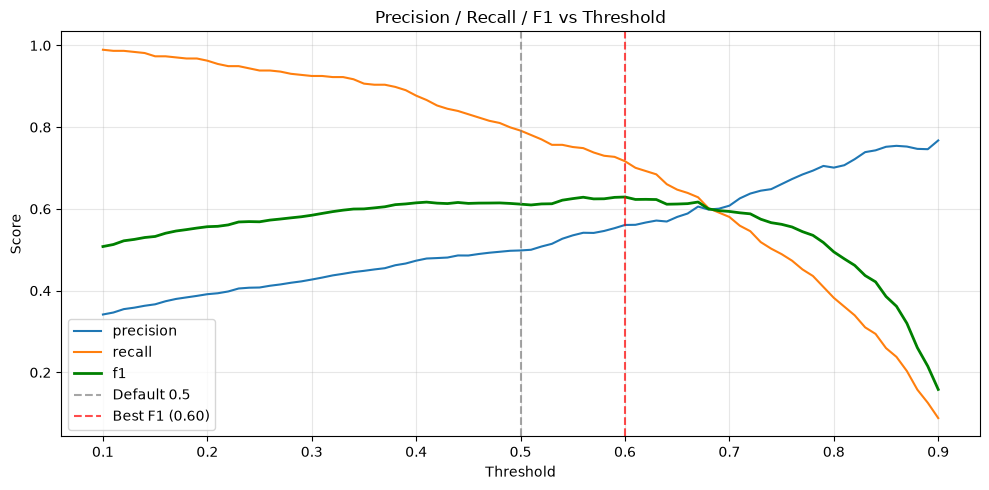

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
for col, color in [("precision", "tab:blue"), ("recall", "tab:orange"), ("f1", "green")]:
    ax.plot(threshold_scan["threshold"], threshold_scan[col], label=col,
            linewidth=2 if col == "f1" else 1.5, color=color)
ax.axvline(0.5, ls="--", color="gray", alpha=0.7, label="Default 0.5")
ax.axvline(threshold_scan.loc[best_idx, "threshold"], ls="--", color="red", alpha=0.7,
           label=f"Best F1 ({threshold_scan.loc[best_idx, 'threshold']:.2f})")
ax.set(xlabel="Threshold", ylabel="Score", title="Precision / Recall / F1 vs Threshold")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / "figures/threshold_tuning.png", dpi=150)
plt.show()

> **Keputusan threshold:** dipilih **0.60** karena memberi **F1 tertinggi (~0.629)** pada test set
> — kompromi terbaik antara menangkap churner (recall ~0.717) dan menekan false alarm (precision ~0.561).

## 5. Business Impact

Menerjemahkan confusion matrix @ threshold final ke rupiah. Asumsi bisnis dikumpulkan
sebagai konstanta di satu tempat agar mudah di-*what-if*.

In [15]:
# === Asumsi bisnis (UBAH DI SINI saja) ===
REVENUE_PER_CUSTOMER = 500_000   # Rp/bulan — ARPU rata-rata (asumsi)
PROMO_COST           = 50_000    # Rp/voucher retensi
RETENTION_RATE       = 0.60      # proporsi churner yg berhasil ditahan setelah di-approach

# === Threshold final (SATU sumber kebenaran) ===
FINAL_THRESHOLD = 0.60

y_pred_final = (y_proba_test >= FINAL_THRESHOLD).astype(int)
final_metrics = {
    "accuracy":  accuracy_score(y_test, y_pred_final),
    "precision": precision_score(y_test, y_pred_final),
    "recall":    recall_score(y_test, y_pred_final),
    "f1":        f1_score(y_test, y_pred_final),
    "roc_auc":   roc_auc_score(y_test, y_proba_test),
}
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()

# === Dampak bisnis ===
kerugian_fn    = fn * REVENUE_PER_CUSTOMER
biaya_fp       = fp * PROMO_COST
revenue_saved  = tp * RETENTION_RATE * REVENUE_PER_CUSTOMER
profit_monthly = revenue_saved - biaya_fp - kerugian_fn

print(f"Threshold final : {FINAL_THRESHOLD}")
print(f"TP={tp} FN={fn} FP={fp} TN={tn}")
for k, v in final_metrics.items():
    print(f"  {k:10s}: {v:.4f}")
print(f"\nRevenue diselamatkan : Rp {revenue_saved:,.0f}")
print(f"Biaya promo (FP)     : Rp {biaya_fp:,.0f}")
print(f"Kerugian miss (FN)   : Rp {kerugian_fn:,.0f}")
print(f"Net profit / bulan   : Rp {profit_monthly:,.0f}")
print(f"Net profit / tahun   : Rp {profit_monthly * 12:,.0f}")

Threshold final : 0.6
TP=268 FN=106 FP=210 TN=825
  accuracy  : 0.7757
  precision : 0.5607
  recall    : 0.7166
  f1        : 0.6291
  roc_auc   : 0.8419

Revenue diselamatkan : Rp 80,400,000
Biaya promo (FP)     : Rp 10,500,000
Kerugian miss (FN)   : Rp 53,000,000
Net profit / bulan   : Rp 16,900,000
Net profit / tahun   : Rp 202,800,000


## 6. Simpan Final Model

Satu run MLflow `logreg-final` memuat **params + metrik teknis + metrik bisnis + artifact model**.
Lalu simpan ke disk untuk dipakai FastAPI (Hari 5).

In [16]:
with mlflow.start_run(run_name="logreg-final"):
    mlflow.log_params({**params_logreg,
                       "threshold": FINAL_THRESHOLD,
                       "selection_reason": "recall+interpretability"})
    mlflow.log_metrics(final_metrics)
    mlflow.log_metrics({"tp": tp, "fn": fn, "fp": fp, "tn": tn,
                        "net_profit_monthly": profit_monthly,
                        "net_profit_yearly": profit_monthly * 12})
    mlflow.sklearn.log_model(model_logreg, name="model")
print("Run 'logreg-final' tercatat di MLflow (params + metrik teknis + bisnis + model)")

Run 'logreg-final' tercatat di MLflow (params + metrik teknis + bisnis + model)


In [17]:
# Simpan model + config konsisten dgn FINAL_THRESHOLD & final_metrics
ARTIFACTS = ROOT / "models"
ARTIFACTS.mkdir(exist_ok=True)
joblib.dump(model_logreg, ARTIFACTS / "model_final.joblib")

config = {
    "model_type":     "LogisticRegression",
    "threshold":      FINAL_THRESHOLD,
    "test_f1":        round(final_metrics["f1"], 4),
    "test_recall":    round(final_metrics["recall"], 4),
    "test_precision": round(final_metrics["precision"], 4),
}
with open(ARTIFACTS / "model_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Tersimpan di models/:")
print("  - model_final.joblib")
print("  - model_config.json ->", config)

Tersimpan di models/:
  - model_final.joblib
  - model_config.json -> {'model_type': 'LogisticRegression', 'threshold': 0.6, 'test_f1': 0.6291, 'test_recall': 0.7166, 'test_precision': 0.5607}
